In [1]:
import os
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.optimize import curve_fit

import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from pollen_utils import get_clients_population_dict
# srun -w mauao -c 5 --partition=interactive --pty bash
# source /nfs-share/ls985/anaconda3/bin/activate ray111-test
# jupyter server --no-browser --port=8889
# ssh -L 8889:localhost:8889 ls985@mauao

# TODO: change font to times new roman
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'normal'#'bold'

In [115]:
root_dir, dataset, batch_size, n_workers = "/nfs-share/ls985/pollen_worker/outputs/2023-10-03/09-53-23", "shakespeare_memory", 10, 10 # Shakespeare w/o partial aggregation
root_dir, dataset, batch_size, n_workers = "/nfs-share/ls985/pollen_worker/outputs/2023-10-03/09-49-25", "shakespeare_memory", 10, 10 # Sharkespeare w/ partial aggregation
root_dir, dataset, batch_size, n_workers = "/nfs-share/ls985/pollen_worker/outputs/2023-10-04/09-14-43", "openimage", 20, 11 # Openimage w/ partial aggregation
root_dir, dataset, batch_size, n_workers = "/nfs-share/ls985/pollen_worker/outputs/2023-10-04/10-50-20", "google_speech", 20, 22 # Google Speech w/ partial aggregation
root_dir, dataset, batch_size, n_workers = "/nfs-share/ls985/pollen_worker/outputs/2023-10-05/09-36-38", "reddit", 20, 14 # Reddit w/ partial aggregation
CLIENTS_TRAINING_STATS = f"{root_dir}/clients_training_stats.parquet"
GPU_STATS = f"{root_dir}/gpu_stats.parquet"

In [116]:
ctd = pq.read_table(CLIENTS_TRAINING_STATS).to_pandas()
gs = pq.read_table(GPU_STATS).to_pandas()

In [117]:
ctd

,cid,start_time,end_time
0,360951,1696495025751836354,1696495037887536867
1,451614,1696495025749090508,1696495037996866774
2,774156,1696495025751758450,1696495038590070343
3,933013,1696495025748395761,1696495038659286075
4,18531,1696495025749843760,1696495038705641878
...,...,...,...
9995,271162,1696498321895544368,1696498323623352733
9996,605704,1696498321692539285,1696498324817846182
9997,181953,1696498320797336260,1696498325147720912
9998,342543,1696498320440359189,1696498325157775267


In [118]:
gs

,index,utilization.gpu [%],memory.total [MiB],memory.used [MiB],memory.free [MiB],temperature.gpu,power.draw [W],clocks.current.sm [MHz],clocks.current.memory [MHz],clocks.current.graphics [MHz],timestamp
0,0,0,45634,2,45632,33,22.18,0,405,0,2023/10/05 09:37:05.792
1,0,0,45634,2,45632,33,22.18,0,405,0,2023/10/05 09:37:05.988
2,0,0,45634,2,45632,32,22.18,0,405,0,2023/10/05 09:37:06.169
3,0,0,45634,2,45632,32,22.18,210,405,210,2023/10/05 09:37:07.171
4,0,0,45634,2,45632,32,24.47,210,405,210,2023/10/05 09:37:07.448
...,...,...,...,...,...,...,...,...,...,...,...
7208,0,100,45634,40824,4810,87,291.74,1590,7250,1590,2023/10/05 10:32:03.794
7209,0,100,45634,40824,4810,87,294.75,1605,7250,1605,2023/10/05 10:32:03.982
7210,0,100,45634,40838,4796,87,292.31,1620,7250,1620,2023/10/05 10:32:04.945
7211,0,100,45634,40862,4772,87,290.40,1560,7250,1560,2023/10/05 10:32:05.144


In [119]:
gs.columns

Index(['index', ' utilization.gpu [%]', ' memory.total [MiB]',
       ' memory.used [MiB]', ' memory.free [MiB]', ' temperature.gpu',
       ' power.draw [W]', ' clocks.current.sm [MHz]',
       ' clocks.current.memory [MHz]', ' clocks.current.graphics [MHz]',
       ' timestamp'],
      dtype='object')

In [120]:
cid_samples_dict = get_clients_population_dict(
    name=dataset,
    batch_size=1,
    seed=1337
)

DEBUG flwr 2023-10-05 11:16:20,592 | pollen_utils.py:360 | Length of cids list before filtering 1628176
DEBUG flwr 2023-10-05 11:16:20,607 | pollen_utils.py:362 | Length of cids list after filtering 1622186
DEBUG flwr 2023-10-05 11:16:20,671 | pollen_utils.py:364 | Randomly sampled clients with state 1337


<Axes: xlabel=' timestamp'>

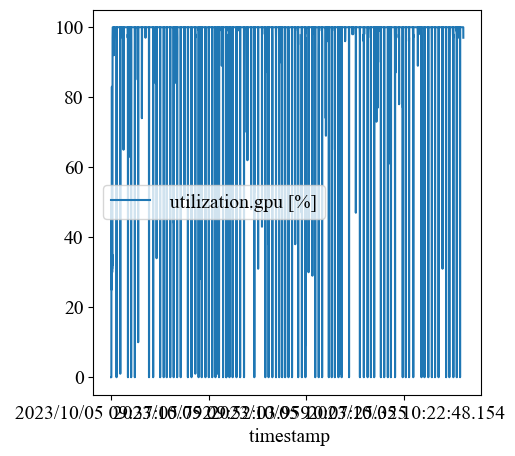

In [121]:
gs.plot(x=" timestamp", y=" utilization.gpu [%]", figsize=(5, 5))

<Axes: xlabel=' timestamp'>

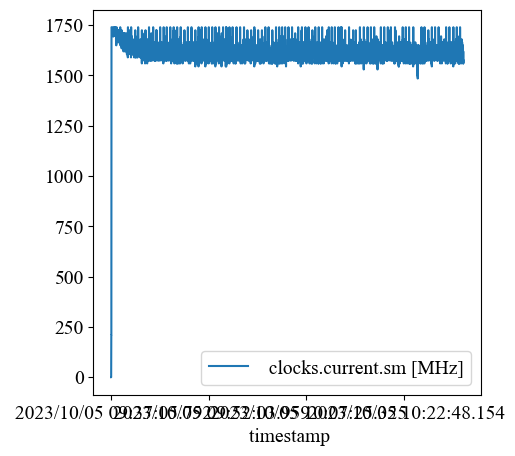

In [122]:
gs.plot(x=" timestamp", y=" clocks.current.sm [MHz]", figsize=(5, 5))

In [123]:
ctd['n_samples'] = ctd['cid'].apply(lambda x: cid_samples_dict[x])
ctd['n_batches'] = ctd['n_samples'] // batch_size

In [124]:
ctd['delta_t'] = ctd['end_time'] - ctd['start_time']
ctd['delta_t_s'] = ctd['delta_t'].apply(lambda x: x * 1e-9)

In [125]:
quantiles = dict()
list_of_batches = list(ctd.n_batches.unique())
list_of_batches.sort()
for bs in list_of_batches:
    # print(bs, ctd[ctd.n_batches == bs]['delta_t_s'].quantile(0.95))
    quantiles[bs] = ctd[ctd.n_batches == bs]['delta_t_s'].quantile(0.95)
ctd['is_outlier'] = ctd.apply(lambda x: x['delta_t_s'] > quantiles[x['n_batches']], axis=1)

In [126]:
ctd[ctd["is_outlier"] == True]

,cid,start_time,end_time,n_samples,n_batches,delta_t,delta_t_s,is_outlier
0,360951,1696495025751836354,1696495037887536867,27,1,12135700513,12.135701,True
1,451614,1696495025749090508,1696495037996866774,28,1,12247776266,12.247776,True
2,774156,1696495025751758450,1696495038590070343,38,1,12838311893,12.838312,True
3,933013,1696495025748395761,1696495038659286075,23,1,12910890314,12.910890,True
4,18531,1696495025749843760,1696495038705641878,25,1,12955798118,12.955798,True
...,...,...,...,...,...,...,...,...
9778,835835,1696498233134635261,1696498259505497005,740,37,26370861744,26.370862,True
9820,1039964,1696498270731760892,1696498274795698581,32,1,4063937689,4.063938,True
9867,1088409,1696498282059838657,1696498285879444216,39,1,3819605559,3.819606,True
9987,526299,1696498317875180834,1696498322090476868,31,1,4215296034,4.215296,True


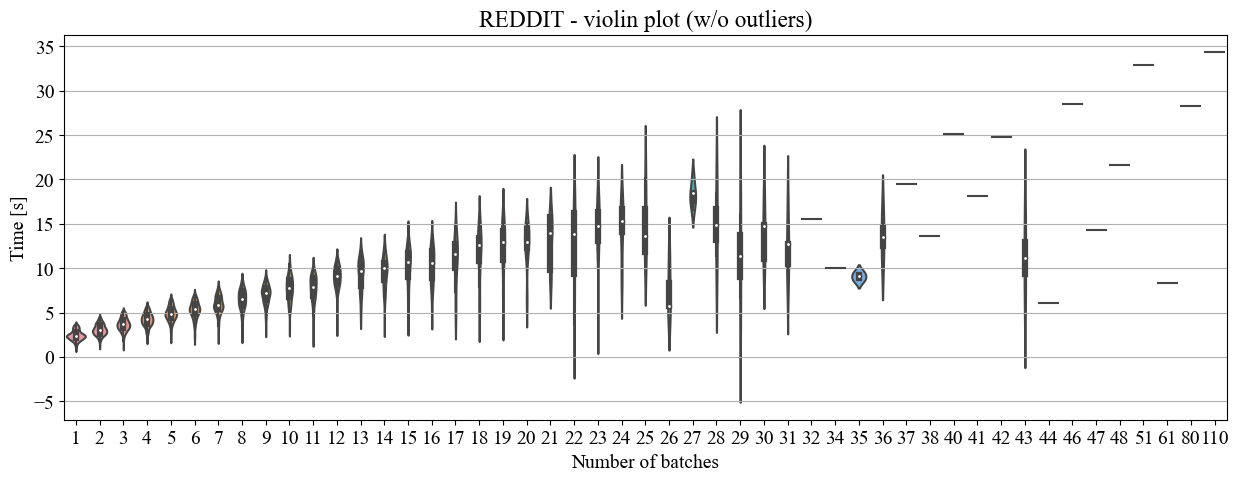

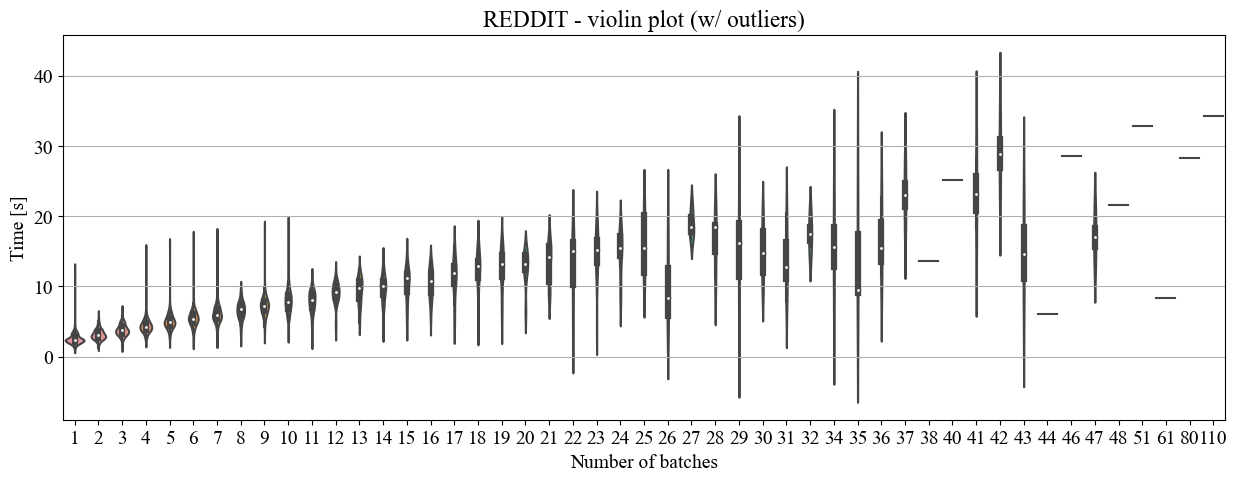

In [127]:
plt.figure(figsize=(15, 5))
sns.violinplot(
    data=ctd[ctd["is_outlier"] == False],
    x="n_batches",
    y="delta_t_s",
)
plt.ylabel("Time [s]")
plt.xlabel("Number of batches")
plt.title(f"{dataset.upper()} - violin plot (w/o outliers)")
plt.grid(axis='y')
plt.savefig(f"{dataset}_violinplot_wo_outliers.pdf", format="pdf", dpi=800, bbox_inches='tight')
plt.show()

plt.figure(figsize=(15, 5))
sns.violinplot(
    data=ctd,
    x="n_batches",
    y="delta_t_s",
)
plt.ylabel("Time [s]")
plt.xlabel("Number of batches")
plt.title(f"{dataset.upper()} - violin plot (w/ outliers)")
plt.grid(axis='y')
plt.savefig(f"{dataset}_violinplot_w_outliers.pdf", format="pdf", dpi=800, bbox_inches='tight')
plt.show()

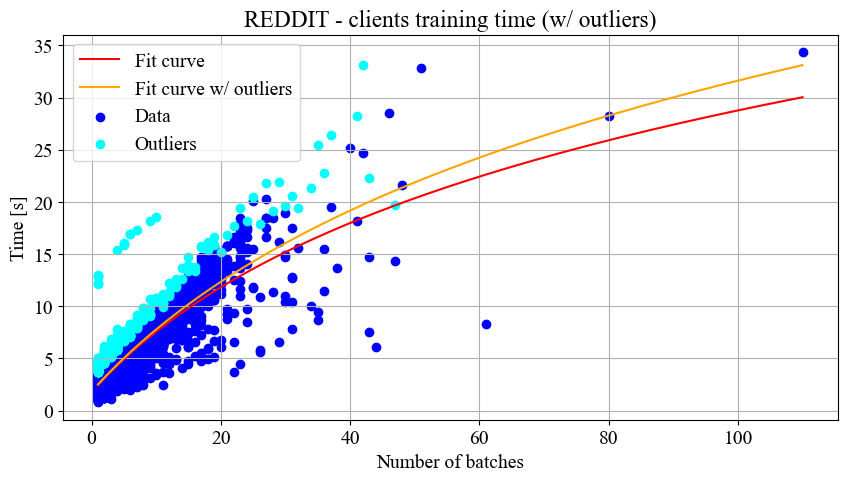

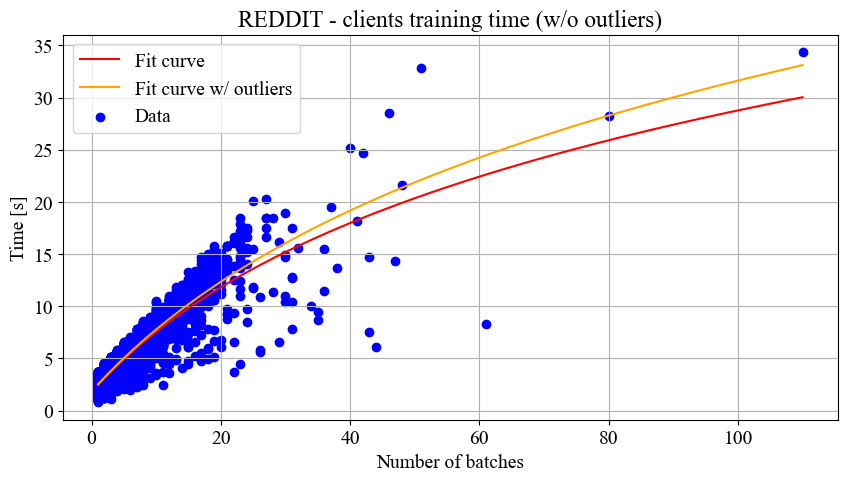

In [128]:
df = ctd[ctd["is_outlier"] == True]
x_data_out = df["n_batches"].values
y_data_out = df["delta_t"].values * 1e-9
df = ctd[ctd["is_outlier"] == False]
x_data = df["n_batches"].values
y_data = df["delta_t"].values * 1e-9
model = lambda x, A, B, offset:  offset+A*np.log(x+B)
popt, pcov = curve_fit(
    model,
    x_data,
    y_data,
    p0=[0,0,0]
)
df = ctd
x_data_all = df["n_batches"].values
y_data_all = df["delta_t"].values * 1e-9
popt_all, pcov_all = curve_fit(
    model,
    x_data_all,
    y_data_all,
    p0=[0,0,0]
)

plt.figure(figsize=(10, 5))
x = np.linspace(x_data.min(),x_data.max(),250)
plt.plot(x, model(x,*popt), label="Fit curve", color="red")
plt.plot(x, model(x,*popt_all), label="Fit curve w/ outliers", color="orange")
plt.scatter(x_data, y_data, label="Data", color="blue")
plt.scatter(x_data_out, y_data_out, label="Outliers", color="cyan")
plt.ylabel("Time [s]")
plt.xlabel("Number of batches")
plt.legend()
plt.title(f"{dataset.upper()} - clients training time (w/ outliers)")
plt.grid()
plt.savefig(f"{dataset}_ctt_data_fit_w_outliers.pdf", format="pdf", dpi=800, bbox_inches='tight')

plt.figure(figsize=(10, 5))
x = np.linspace(x_data.min(),x_data.max(),250)
plt.plot(x, model(x,*popt), label="Fit curve", color="red")
plt.plot(x, model(x,*popt_all), label="Fit curve w/ outliers", color="orange")
plt.scatter(x_data, y_data, label="Data", color="blue")
plt.ylabel("Time [s]")
plt.xlabel("Number of batches")
plt.legend()
plt.title(f"{dataset.upper()} - clients training time (w/o outliers)")
plt.grid()
plt.savefig(f"{dataset}_ctt_data_fit_wo_outliers.pdf", format="pdf", dpi=800, bbox_inches='tight')